# Predicting Tips Using Linear Regression

### Data Set Description:
* 'Tip' dataset included in the seaborn library
* Informations about tips given to waiters in a restaurant
* Contains 244 entries, each representing a meal at a restaurant
* Includes information about the total bill, tip amount, and various factors that might influence tipping behavior.

### The workflow:
1. Data exploration and preprocessing
2. Feature selection and engineering
3. Model implementation (Start with simple models and progressively adding complexity)
4. Model evaluation and comparison
5. Interpretation of results

## Data Exploration and Preprocessing

In [1]:
# Importing necessary libraries
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [21]:
# Load the tips dataset form the seaborn library
tips_df = sns.load_dataset('tips') # Return pandas dataframe

In [22]:
# Display the fisrt few rows and basic info
tips_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


In [23]:
# Can see the key features of the dataset
tips_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype   
---  ------      --------------  -----   
 0   total_bill  244 non-null    float64 
 1   tip         244 non-null    float64 
 2   sex         244 non-null    category
 3   smoker      244 non-null    category
 4   day         244 non-null    category
 5   time        244 non-null    category
 6   size        244 non-null    int64   
dtypes: category(4), float64(2), int64(1)
memory usage: 7.4 KB


## Handling Missing Values

In [24]:
# check null values
tips_df.isnull().sum() # sum() helps to see how many missing values exist in each feature

total_bill    0
tip           0
sex           0
smoker        0
day           0
time          0
size          0
dtype: int64

## Exploratory Data Analysis  (EDA)

Text(0.5, 1.0, 'Distribution of Tip Amounts')

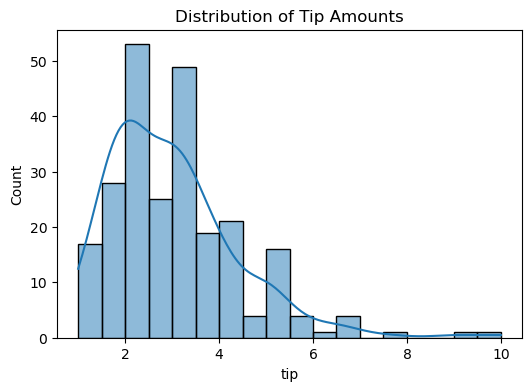

In [25]:
# Visualizing some key aspects of the data
# Distribution of tip amounts
plt.figure(figsize=(6, 4))
sns.histplot(tips_df['tip'], kde=True)
plt.title("Distribution of Tip Amounts")

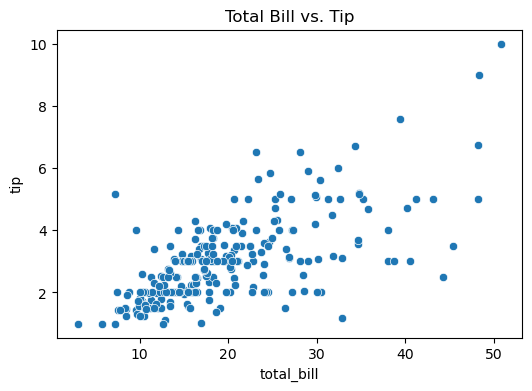

In [26]:
# Relationship between total bill and tip
plt.figure(figsize=(6, 4))
sns.scatterplot(x='total_bill', y='tip', data=tips_df)
plt.title('Total Bill vs. Tip')
plt.show()

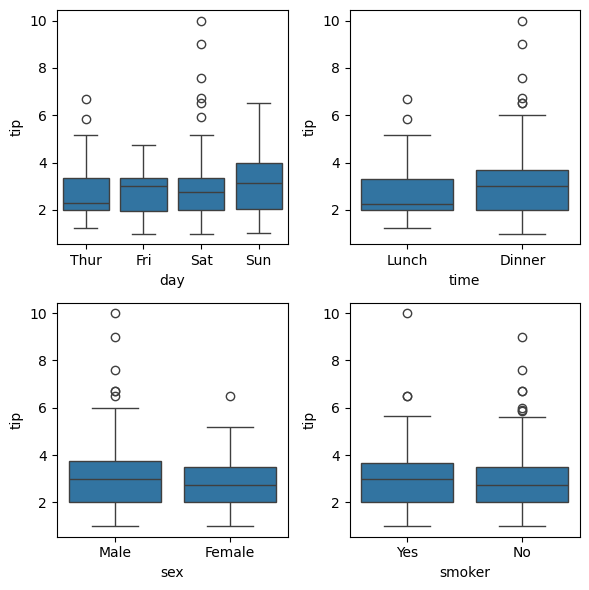

In [27]:
# Box plots for categorical variables
fig, axes = plt.subplots(2, 2, figsize=(6, 6))
sns.boxplot(x='day', y='tip', data=tips_df, ax=axes[0, 0])
sns.boxplot(x='time', y='tip', data=tips_df, ax=axes[0, 1])
sns.boxplot(x='sex', y='tip', data=tips_df, ax=axes[1, 0])
sns.boxplot(x='smoker', y='tip', data=tips_df, ax=axes[1, 1])
plt.tight_layout()
plt.show()

The distribution of the tips is normal. \
There seems to be a linear relationship between total bill and tip
Patterns in the tipping based on each categorical variable:
* ppl will tip more on Sundays compared to other days
* Tipping is more for dinners compared to lunches
* Men tip more compared to women
* Smoker doesn't seem to play bold role in tipping

In [28]:
# We can see the counts for each category
tips_df.time.value_counts()

time
Dinner    176
Lunch      68
Name: count, dtype: int64

In [29]:
tips_df.sex.value_counts()

sex
Male      157
Female     87
Name: count, dtype: int64

In [30]:
tips_df.day.value_counts()

day
Sat     87
Sun     76
Thur    62
Fri     19
Name: count, dtype: int64

## Feature Encoding
Encode our categorical variables

In [31]:
# Categorical encoding for 'sex', 'smoker', and 'time'
# for categorical properties that we can map to binary values, like 'sex' we can use the code below or use 'cat.codes'
# tips_df['sex'] = tips_df['sex'].map({'Male': 1, 'Female':0})
tips_df['sex'] = tips_df['sex'].cat.codes
tips_df['smoker'] = tips_df['smoker'].cat.codes
tips_df['time'] = tips_df['time'].cat.codes

In [32]:
tips_df

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,1,1,Sun,1,2
1,10.34,1.66,0,1,Sun,1,3
2,21.01,3.50,0,1,Sun,1,3
3,23.68,3.31,0,1,Sun,1,2
4,24.59,3.61,1,1,Sun,1,4
...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,Sat,1,3
240,27.18,2.00,1,0,Sat,1,2
241,22.67,2.00,0,0,Sat,1,2
242,17.82,1.75,0,1,Sat,1,2


The feature 'day' is a categorical feature with more than two categories and are not considered as ranked.   
In this case we create dummy features, i.e., whether the day is saturday or not, or whether the day is sunday or not. -> kinda like we make it binary
We transform the featue 'day' into 4 features: day_Thur, day_Fri, day_Sat, day_Sun

In [33]:
# One-hot encoding for 'day
tips_df = pd.get_dummies(tips_df, columns=['day'])

In [34]:
tips_df.head()

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun
0,16.99,1.01,1,1,1,2,False,False,False,True
1,10.34,1.66,0,1,1,3,False,False,False,True
2,21.01,3.50,0,1,1,3,False,False,False,True
3,23.68,3.31,0,1,1,2,False,False,False,True
4,24.59,3.61,1,1,1,4,False,False,False,True


## Feature Scaling
StandardScaler from sklearn.preprocessing \
-> subtracts the mean of the column from each entry and then divide it by the standard deviation of the training samples. \
-> Normal distribution with mean=0 and sigma2=1\
'DO NOT DO IT HERE'

In [106]:
from sklearn.preprocessing import StandardScaler

In [107]:
scaler = StandardScaler()

In [108]:
#numerical_features = ['total_bill', 'size']
#tips_df[numerical_features] = scaler.fit_transform(tips_df[numerical_features])

In [109]:
tips_df

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun
0,16.99,1.01,1,1,1,2,False,False,False,True
1,10.34,1.66,0,1,1,3,False,False,False,True
2,21.01,3.50,0,1,1,3,False,False,False,True
3,23.68,3.31,0,1,1,2,False,False,False,True
4,24.59,3.61,1,1,1,4,False,False,False,True
...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,1,3,False,False,True,False
240,27.18,2.00,1,0,1,2,False,False,True,False
241,22.67,2.00,0,0,1,2,False,False,True,False
242,17.82,1.75,0,1,1,2,False,False,True,False


## Preparing for Modelling

In [35]:
# Separate features and target variables
X = tips_df.drop(columns='tip')
y = tips_df['tip']

In [36]:
y

0      1.01
1      1.66
2      3.50
3      3.31
4      3.61
       ... 
239    5.92
240    2.00
241    2.00
242    1.75
243    3.00
Name: tip, Length: 244, dtype: float64

In [37]:
y.name

'tip'

In [38]:
X.columns

Index(['total_bill', 'sex', 'smoker', 'time', 'size', 'day_Thur', 'day_Fri',
       'day_Sat', 'day_Sun'],
      dtype='object')

## Feature Selection and Engineering
Selecting the most relevant features\
Create new features that might enhance our model's performance

### Correlation Analysis
Examine the correlations between our features and the target variables.

In [39]:
# Calculate correlations
corr_matrix = tips_df.corr()

In [40]:
# which features have the srongest correlations with tip
corr_matrix['tip'].sort_values(ascending=False)

tip           1.000000
total_bill    0.675734
size          0.489299
day_Sun       0.125114
time          0.121629
day_Sat      -0.002790
smoker       -0.005929
day_Fri      -0.055463
sex          -0.088862
day_Thur     -0.095879
Name: tip, dtype: float64

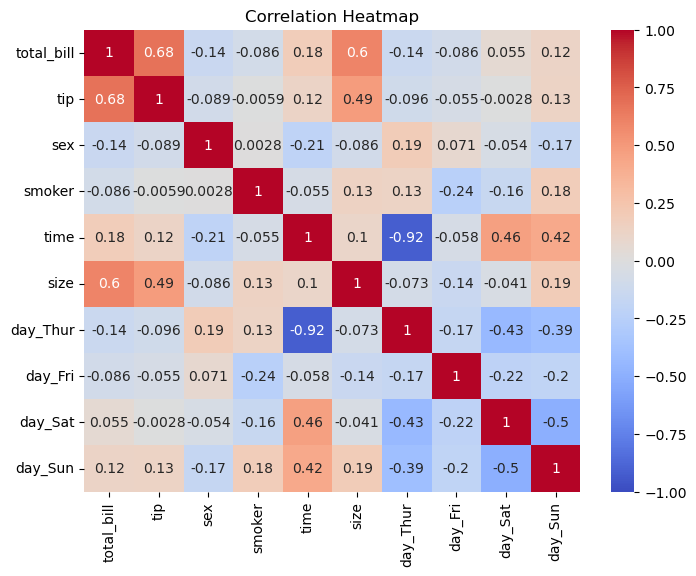

In [41]:
# Plot correlation heatmap
plt.figure(figsize=(8, 6))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', vmin=-1, vmax=1, center=0)
plt.title('Correlation Heatmap')
plt.show()

## Visualizing Relationships
USe scatter plots to visualize the relationship between numerical features and the tip amount

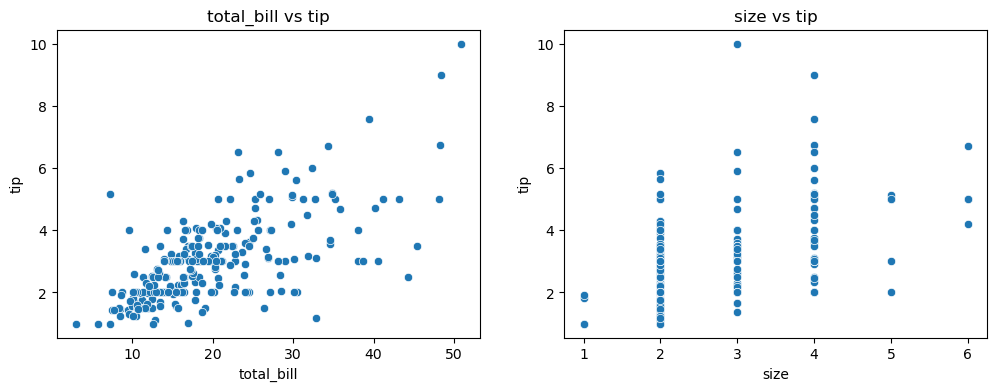

In [42]:
numerical_features = ['total_bill', 'size']
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

for i, feature in enumerate(numerical_features):
    sns.scatterplot(x=feature, y='tip', data=tips_df, ax=axes[i])
    axes[i].set_title(f'{feature} vs tip')

## Selecting Initial Features
Based on the correlations and visualization, select our initial set of features.

In [59]:
selected_features = ['total_bill', 'size', 'time',  'day_Sat', 'day_Sun']
X_selected = tips_df[selected_features]
print("Selected feature:", X_selected.columns)

Selected feature: Index(['total_bill', 'size', 'time', 'day_Sat', 'day_Sun'], dtype='object')


In [60]:
X_selected

,total_bill,size,time,day_Sat,day_Sun
0,16.99,2,1,False,True
1,10.34,3,1,False,True
2,21.01,3,1,False,True
3,23.68,2,1,False,True
4,24.59,4,1,False,True
...,...,...,...,...,...
239,29.03,3,1,True,False
240,27.18,2,1,True,False
241,22.67,2,1,True,False
242,17.82,2,1,True,False


## Feature Engineering
Create some new features that might improve our model

In [61]:
# Tip Percentage
tips_df['tip_percentage'] = tips_df['tip'] / tips_df['total_bill'] * 100
tips_df

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun,tip_percentage,per_person_total,is_weekend,party_Small,party_Medium,party_Large
0,16.99,1.01,1,1,1,2,False,False,False,True,5.944673,8.495000,True,True,False,False
1,10.34,1.66,0,1,1,3,False,False,False,True,16.054159,3.446667,True,True,False,False
2,21.01,3.50,0,1,1,3,False,False,False,True,16.658734,7.003333,True,True,False,False
3,23.68,3.31,0,1,1,2,False,False,False,True,13.978041,11.840000,True,True,False,False
4,24.59,3.61,1,1,1,4,False,False,False,True,14.680765,6.147500,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,1,3,False,False,True,False,20.392697,9.676667,True,True,False,False
240,27.18,2.00,1,0,1,2,False,False,True,False,7.358352,13.590000,True,True,False,False
241,22.67,2.00,0,0,1,2,False,False,True,False,8.822232,11.335000,True,True,False,False
242,17.82,1.75,0,1,1,2,False,False,True,False,9.820426,8.910000,True,True,False,False


In [62]:
# Per Person Total
tips_df['per_person_total'] = tips_df['total_bill'] / tips_df['size']
tips_df

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun,tip_percentage,per_person_total,is_weekend,party_Small,party_Medium,party_Large
0,16.99,1.01,1,1,1,2,False,False,False,True,5.944673,8.495000,True,True,False,False
1,10.34,1.66,0,1,1,3,False,False,False,True,16.054159,3.446667,True,True,False,False
2,21.01,3.50,0,1,1,3,False,False,False,True,16.658734,7.003333,True,True,False,False
3,23.68,3.31,0,1,1,2,False,False,False,True,13.978041,11.840000,True,True,False,False
4,24.59,3.61,1,1,1,4,False,False,False,True,14.680765,6.147500,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,1,3,False,False,True,False,20.392697,9.676667,True,True,False,False
240,27.18,2.00,1,0,1,2,False,False,True,False,7.358352,13.590000,True,True,False,False
241,22.67,2.00,0,0,1,2,False,False,True,False,8.822232,11.335000,True,True,False,False
242,17.82,1.75,0,1,1,2,False,False,True,False,9.820426,8.910000,True,True,False,False


In [63]:
# Is Weekend
tips_df['is_weekend'] = tips_df['day_Sat'] | tips_df['day_Sun']
tips_df

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun,tip_percentage,per_person_total,is_weekend,party_Small,party_Medium,party_Large
0,16.99,1.01,1,1,1,2,False,False,False,True,5.944673,8.495000,True,True,False,False
1,10.34,1.66,0,1,1,3,False,False,False,True,16.054159,3.446667,True,True,False,False
2,21.01,3.50,0,1,1,3,False,False,False,True,16.658734,7.003333,True,True,False,False
3,23.68,3.31,0,1,1,2,False,False,False,True,13.978041,11.840000,True,True,False,False
4,24.59,3.61,1,1,1,4,False,False,False,True,14.680765,6.147500,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,1,3,False,False,True,False,20.392697,9.676667,True,True,False,False
240,27.18,2.00,1,0,1,2,False,False,True,False,7.358352,13.590000,True,True,False,False
241,22.67,2.00,0,0,1,2,False,False,True,False,8.822232,11.335000,True,True,False,False
242,17.82,1.75,0,1,1,2,False,False,True,False,9.820426,8.910000,True,True,False,False


In [64]:
# Party Size Category
tips_df['party_size_category'] = pd.cut(
    tips_df['size'], 
    bins=[0, 3, 6, np.inf], 
    labels=['Small', 'Medium', 'Large']
    )
tips_df = pd.get_dummies(tips_df, columns=['party_size_category'], prefix='party')
tips_df

,total_bill,tip,sex,smoker,time,size,day_Thur,day_Fri,day_Sat,day_Sun,tip_percentage,per_person_total,is_weekend,party_Small,party_Medium,party_Large,party_Small,party_Medium,party_Large
0,16.99,1.01,1,1,1,2,False,False,False,True,5.944673,8.495000,True,True,False,False,True,False,False
1,10.34,1.66,0,1,1,3,False,False,False,True,16.054159,3.446667,True,True,False,False,True,False,False
2,21.01,3.50,0,1,1,3,False,False,False,True,16.658734,7.003333,True,True,False,False,True,False,False
3,23.68,3.31,0,1,1,2,False,False,False,True,13.978041,11.840000,True,True,False,False,True,False,False
4,24.59,3.61,1,1,1,4,False,False,False,True,14.680765,6.147500,True,False,True,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
239,29.03,5.92,0,1,1,3,False,False,True,False,20.392697,9.676667,True,True,False,False,True,False,False
240,27.18,2.00,1,0,1,2,False,False,True,False,7.358352,13.590000,True,True,False,False,True,False,False
241,22.67,2.00,0,0,1,2,False,False,True,False,8.822232,11.335000,True,True,False,False,True,False,False
242,17.82,1.75,0,1,1,2,False,False,True,False,9.820426,8.910000,True,True,False,False,True,False,False


In [65]:
tips_df.filter(like='party_').columns

Index(['party_Small', 'party_Medium', 'party_Large', 'party_Small',
       'party_Medium', 'party_Large'],
      dtype='object')

In [66]:
party_size_columns = tips_df.filter(like='party_').columns.tolist()
tips_df[['tip', 'tip_percentage', 'per_person_total', 'is_weekend'] + party_size_columns].head()

,tip,tip_percentage,per_person_total,is_weekend,party_Small,party_Small,party_Medium,party_Medium,party_Large,party_Large,party_Small,party_Small,party_Medium,party_Medium,party_Large,party_Large
0,1.01,5.944673,8.495000,True,True,True,False,False,False,False,True,True,False,False,False,False
1,1.66,16.054159,3.446667,True,True,True,False,False,False,False,True,True,False,False,False,False
2,3.50,16.658734,7.003333,True,True,True,False,False,False,False,True,True,False,False,False,False
3,3.31,13.978041,11.840000,True,True,True,False,False,False,False,True,True,False,False,False,False
4,3.61,14.680765,6.147500,True,False,False,True,True,False,False,False,False,True,True,False,False


### Updating Selected Features

In [67]:
# Updating Selected Features to include engineered features

selected_features = ['total_bill', 'size', 'time', 'day_Sat', 'day_Sun', 'tip_percentage', 'per_person_total', 'is_weekend'] + [col for col in tips_df.columns if col.startswith('party_')]
X_selected = tips_df[selected_features]

print("Updated selected features:", X_selected.columns)

Updated selected features: Index(['total_bill', 'size', 'time', 'day_Sat', 'day_Sun', 'tip_percentage',
       'per_person_total', 'is_weekend', 'party_Small', 'party_Small',
       'party_Medium', 'party_Medium', 'party_Large', 'party_Large',
       'party_Small', 'party_Small', 'party_Medium', 'party_Medium',
       'party_Large', 'party_Large'],
      dtype='object')


## Preparing Finel Dataset for Modelling

In [68]:
from sklearn.model_selection import train_test_split

X = X_selected.astype(np.float64) # astype(np.float64) -> to make sure that the values are float type
y = tips_df['tip'].astype(np.float64)

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("Training set shape:", X_train.shape)
print("Testing set shape:", X_test.shape)

Training set shape: (195, 20)
Testing set shape: (49, 20)


In [69]:
# Check if the dimensions matches
assert X_train.shape[0] + X_test.shape[0] == tips_df.shape[0], "Training and testing sets do not match the original dataset size"
assert X_train.shape[1] == X_test.shape[1], "Training and testing sets do not have the same number of features"

In [70]:
def add_bias_column(X):
    return np.c_[np.ones((X.shape[0], 1)), X]

# Add a column of ones to X for the intercept term
X_train = add_bias_column(X_train)
X_test = add_bias_column(X_test)

y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)

## Implementing Multiple Linear Regression

In [71]:
from sklearn.linear_model import LinearRegression

# Initialize the model
lr_model = LinearRegression()

# Fit the model
lr_model.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [72]:
lr_model.coef_

array([[ 0.00000000e+000,  1.29741305e-001,  1.55526849e-001,
        -7.07792346e-002,  3.79227478e-002, -7.32885787e-002,
         1.46665680e-001,  9.66458461e-003, -3.53658309e-002,
        -3.95137177e-003, -3.95137177e-003,  3.95137177e-003,
         3.95137177e-003,  0.00000000e+000,  5.96114378e-108,
        -3.95137177e-003, -3.95137177e-003,  3.95137177e-003,
         3.95137177e-003,  0.00000000e+000,  0.00000000e+000]])

In [73]:
lr_model.intercept_

array([-2.28634038])

## Model Evaluation

In [74]:
from sklearn.metrics import mean_squared_error, r2_score

def evaluate_model(model, X_train, y_train, X_test, y_test):
    # Training set performance
    y_train_pred = model.predict(X_train)
    mse_train = mean_squared_error(y_train, y_train_pred)
    rmse_train = np.sqrt(mse_train)
    r2_train = r2_score(y_train, y_train_pred)

    # Test set performance
    y_test_pred = model.predict(X_test)
    mse_test = mean_squared_error(y_test, y_test_pred)
    rmse_test = np.sqrt(mse_test)
    r2_test = r2_score(y_test, y_test_pred)

    print("Training Set Results:")
    print(f"Mean Squared Error: {mse_train}")
    print(f"R-squared: {r2_train}")
    print(f"Root Mean Squared Error: {rmse_train}")
    print("\nTest Set Results:")
    print(f"Mean Squared Error: {mse_test}")
    print(f"R-squared: {r2_test}")
    print(f"Root Mean Squared Error: {rmse_test}")
    return mse_train, rmse_train, r2_train, mse_test, rmse_test, r2_test

# Evaluate the model
mse_train, rmse_train, r2_train, mse_test, rmse_test, r2_test = evaluate_model(lr_model, X_train, y_train, X_test, y_test)

Training Set Results:
Mean Squared Error: 0.35284436432551836
R-squared: 0.826331116137727
Root Mean Squared Error: 0.5940070406363197

Test Set Results:
Mean Squared Error: 0.21557248782631053
R-squared: 0.8275380562589918
Root Mean Squared Error: 0.46429784387428563


R-squared = 0.82 means that 82% of the variation in the tip is predictable with our data.\
Mean squared error = 0.21 , mean error of the predicted tip

### Visualizing Predictions

Text(0.5, 1.0, 'Actual vs Predicted Tips (Test Set)')

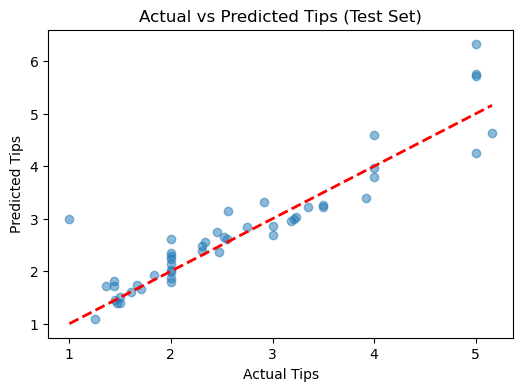

In [75]:
y_test_pred = lr_model.predict(X_test)

plt.figure(figsize=(6, 4))
plt.scatter(y_test, y_test_pred, alpha=0.5)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual Tips")
plt.ylabel("Predicted Tips")
plt.title("Actual vs Predicted Tips (Test Set)")

### Residual Analysis

Text(0.5, 1.0, 'Residual Plot (Test Set)')

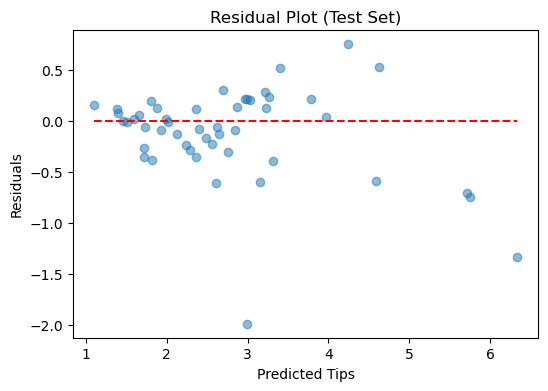

In [76]:
residuals = y_test - y_test_pred

plt.figure(figsize=(6, 4))
plt.scatter(y_test_pred, residuals, alpha=0.5)
plt.hlines(y=0, xmin=y_test_pred.min(), xmax=y_test_pred.max(), colors='r', linestyles='--')
plt.xlabel("Predicted Tips")
plt.ylabel("Residuals")
plt.title("Residual Plot (Test Set)")

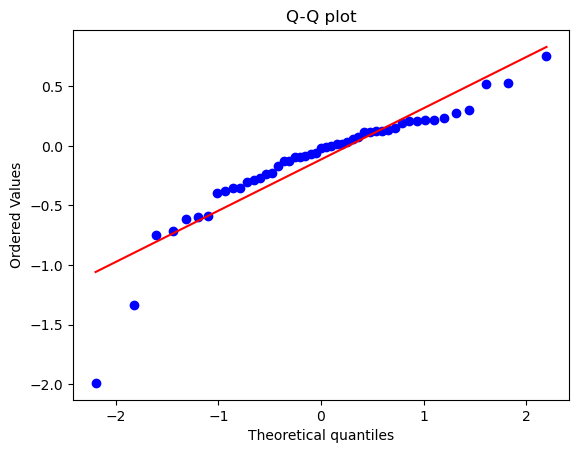

In [77]:
import scipy.stats as stats

fig, ax = plt.subplots()
stats.probplot((y_test - y_test_pred).reshape(-1), plot=ax, fit=True, dist='norm')
ax.set_title("Q-Q plot")
plt.show()

## Polynomial Regression and Regularization
Potentially improve our multiple linear regression model.

## Implementing Ridge Regression
Ridge regression (L2 regularization) adds a penalty term proportional to the square of the magnitude of coefficients.

In [78]:
from sklearn.linear_model import Ridge
from sklearn.model_selection import cross_val_score

In [79]:
# Initialize Ridge model
ridge_model = Ridge(alpha=1.0)  # alpha is the regularization strength

In [80]:
# Fit the model
ridge_model.fit(X_train, y_train)

,alpha,1.0
,fit_intercept,True
,copy_X,True
,max_iter,None
,tol,0.0001
,solver,'auto'
,positive,False
,random_state,None


In [81]:
# Evaluate the model
print("Ridge Regression Results:")
evaluate_model(ridge_model, X_train, y_train, X_test, y_test)

Ridge Regression Results:
Training Set Results:
Mean Squared Error: 0.3528525846357279
R-squared: 0.8263270701269545
Root Mean Squared Error: 0.5940139599670431

Test Set Results:
Mean Squared Error: 0.21640247569198273
R-squared: 0.8268740507449366
Root Mean Squared Error: 0.46519079493470494


(0.3528525846357279,
 np.float64(0.5940139599670431),
 0.8263270701269545,
 0.21640247569198273,
 np.float64(0.46519079493470494),
 0.8268740507449366)

in this example we already did a lot of feature engineering and our data was not even that big, so the regularization does not look like did a lot enhancement.

In [82]:
# Print coefficients
print("\nRidge Coefficients:")
for feature, coef in zip(X.columns, ridge_model.coef_):
    print(f"{feature}: {coef}")


Ridge Coefficients:
total_bill: 0.0
size: 0.1307112536219127
time: 0.1458011093027986
day_Sat: -0.06718734848550116
day_Sun: 0.03600292970358212
tip_percentage: -0.07268454107020395
per_person_total: 0.14658257293491442
is_weekend: 0.007185938834627841
party_Small: -0.03668161136659776
party_Small: -0.004611680901032536
party_Medium: -0.0046116809010324986
party_Medium: 0.004611680901032492
party_Large: 0.0046116809010324795
party_Large: 0.0
party_Small: 0.0
party_Small: -0.004611680901032481
party_Medium: -0.00461168090102709
party_Medium: 0.004611680901027089
party_Large: 0.0046116809010270975
party_Large: 0.0


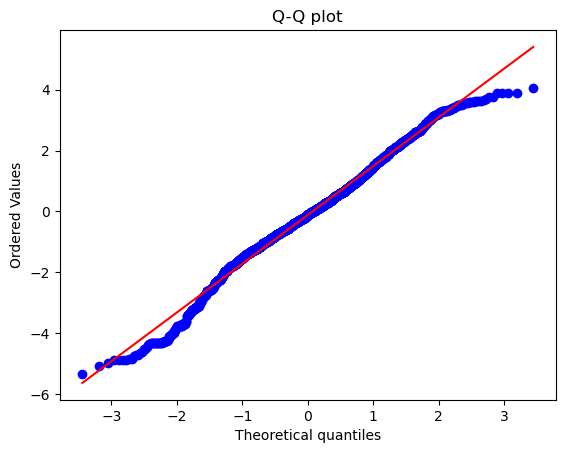

In [ ]:
import scipy.stats as stats

y_test_pred = ridge_model.predict(X_test)
fig, ax = plt.subplots()
stats.probplot((y_test - y_test_pred).reshape(-1), plot=ax, fit=True, dist='norm')
ax.set_title("Q-Q plot")
plt.show()

## Implementing Lasso Regression

Lasso regression (L1 regularization) adds a penalty term proportional to the absolute value of the magnitude of coefficients. \
This can lead to sparse models by driving some coefficients to exactly zero.

In [84]:
from sklearn.linear_model import Lasso

# Initialize Lasso model
lasso_model = Lasso(alpha=0.01)  # alpha is the regularization strength

# Fit the model
lasso_model.fit(X_train, y_train)

,alpha,0.01
,fit_intercept,True
,precompute,False
,copy_X,True
,max_iter,1000
,tol,0.0001
,warm_start,False
,positive,False
,random_state,None
,selection,'cyclic'


In [85]:
# Evaluate the model
print("\nLasso Regression Results:")
evaluate_model(lasso_model, X_train, y_train, X_test, y_test)


Lasso Regression Results:
Training Set Results:
Mean Squared Error: 0.3540957960099648
R-squared: 0.8257151654074861
Root Mean Squared Error: 0.5950594894714013

Test Set Results:
Mean Squared Error: 0.21635859333723376
R-squared: 0.8269091574335138
Root Mean Squared Error: 0.4651436265684329


(0.3540957960099648,
 np.float64(0.5950594894714013),
 0.8257151654074861,
 0.21635859333723376,
 np.float64(0.4651436265684329),
 0.8269091574335138)

In [86]:
# Print non-zero coefficients
print("\nLasso Coefficients (non-zero):")
for feature, coef in zip(X.columns, lasso_model.coef_):
    if coef != 0:
        print(f"{feature}: {coef}")


Lasso Coefficients (non-zero):
size: 0.13732946193726142
time: 0.09619096791660277
day_Sat: -0.034735423914693704
tip_percentage: -0.06595481503950786
per_person_total: 0.1456968918713743
is_weekend: -0.009804925811238152


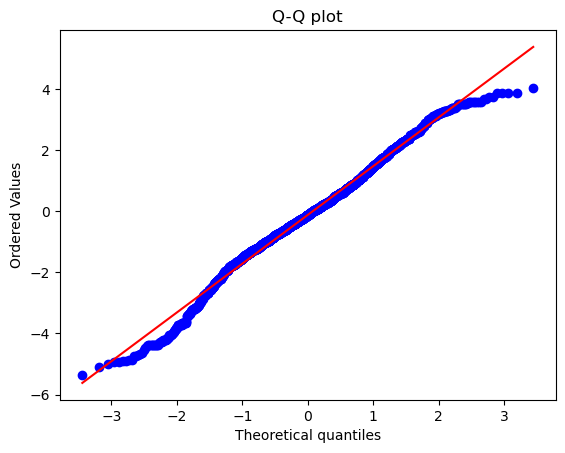

In [87]:
import scipy.stats as stats

y_test_pred = lasso_model.predict(X_test)
fig, ax = plt.subplots()
stats.probplot((y_test - y_test_pred).reshape(-1), plot=ax, fit=True, dist='norm')
ax.set_title("Q-Q plot")
plt.show()

## Comparing Models

### Visualizing Coefficient Changes

(array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
        17, 18, 19, 20]),
 [Text(0, 0, 'Bias'),
  Text(1, 0, 'total_bill'),
  Text(2, 0, 'size'),
  Text(3, 0, 'time'),
  Text(4, 0, 'day_Sat'),
  Text(5, 0, 'day_Sun'),
  Text(6, 0, 'tip_percentage'),
  Text(7, 0, 'per_person_total'),
  Text(8, 0, 'is_weekend'),
  Text(9, 0, 'party_Small'),
  Text(10, 0, 'party_Small'),
  Text(11, 0, 'party_Medium'),
  Text(12, 0, 'party_Medium'),
  Text(13, 0, 'party_Large'),
  Text(14, 0, 'party_Large'),
  Text(15, 0, 'party_Small'),
  Text(16, 0, 'party_Small'),
  Text(17, 0, 'party_Medium'),
  Text(18, 0, 'party_Medium'),
  Text(19, 0, 'party_Large'),
  Text(20, 0, 'party_Large')])

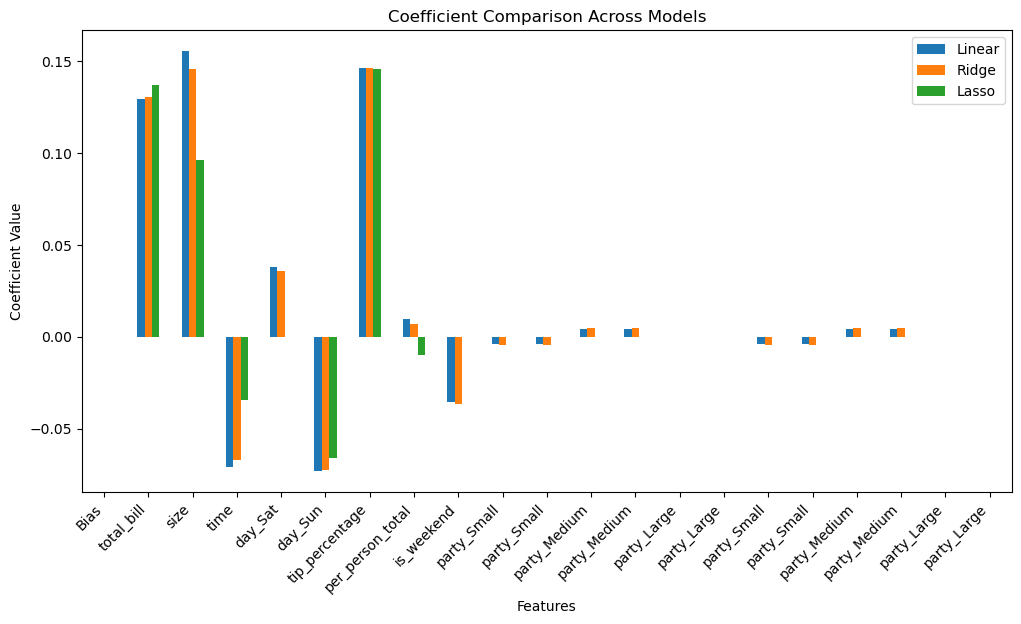

In [88]:
import matplotlib.pyplot as plt

coef_df = pd.DataFrame({
    'Linear': lr_model.coef_.flatten(),
    'Ridge': ridge_model.coef_.flatten(),
    'Lasso': lasso_model.coef_.flatten()
}, index=['Bias'] + list(X.columns))

coef_df.plot(kind='bar', figsize=(12, 6))
plt.title('Coefficient Comparison Across Models')
plt.xlabel('Features')
plt.ylabel('Coefficient Value')
plt.legend(loc='best')
plt.xticks(rotation=45, ha='right')

## Tuning Regularization Strength

The alpha parameter controls the strength of regularization. \
Let's use cross-validation to find the best alpha for Ridge regression:

In [89]:
from sklearn.model_selection import GridSearchCV

# Define the parameter grid
param_grid = {'alpha': [0.001, 0.01, 0.1, 1, 10, 100]}

# Create a GridSearchCV object
grid_search = GridSearchCV(Ridge(), param_grid, cv=5, scoring='neg_mean_squared_error')

# Fit the grid search
grid_search.fit(X_train, y_train)

# Print the best parameters and score
print("Best parameters:", grid_search.best_params_)
print("Best negative MSE:", -grid_search.best_score_)

# Use the best model for final evaluation
best_ridge_model = grid_search.best_estimator_
print("\nBest Ridge Model Results:")
evaluate_model(best_ridge_model, X_train, y_train, X_test, y_test)

Best parameters: {'alpha': 100}
Best negative MSE: 0.5182952404785459

Best Ridge Model Results:
Training Set Results:
Mean Squared Error: 0.3557660250227767
R-squared: 0.8248930839523836
Root Mean Squared Error: 0.5964612519039076

Test Set Results:
Mean Squared Error: 0.21838811625177806
R-squared: 0.8252855018815528
Root Mean Squared Error: 0.4673201432121004


(0.3557660250227767,
 np.float64(0.5964612519039076),
 0.8248930839523836,
 0.21838811625177806,
 np.float64(0.4673201432121004),
 0.8252855018815528)

## Comparing All Models

In [90]:
models = {
    "Multiple Linear Regression": lr_model,
    "Ridge Regression": ridge_model,
    "Lasso Regression": lasso_model
}

results = []

for name, model in models.items():
    mse_train, rmse_train, r2_train, mse_test, rmse_test, r2_test = evaluate_model(model, X_train, y_train, X_test, y_test)
    results.append({
        "Model": name,
        "Train MSE": mse_train,
        "Train R2": r2_train,
        "Test MSE": mse_test,
        "Test R2": r2_test,
        "Train RMSE": np.sqrt(mse_train),
        "Test RMSE": np.sqrt(mse_test)
    })

results_df = pd.DataFrame(results)
print(results_df)

Training Set Results:
Mean Squared Error: 0.35284436432551836
R-squared: 0.826331116137727
Root Mean Squared Error: 0.5940070406363197

Test Set Results:
Mean Squared Error: 0.21557248782631053
R-squared: 0.8275380562589918
Root Mean Squared Error: 0.46429784387428563
Training Set Results:
Mean Squared Error: 0.3528525846357279
R-squared: 0.8263270701269545
Root Mean Squared Error: 0.5940139599670431

Test Set Results:
Mean Squared Error: 0.21640247569198273
R-squared: 0.8268740507449366
Root Mean Squared Error: 0.46519079493470494
Training Set Results:
Mean Squared Error: 0.3540957960099648
R-squared: 0.8257151654074861
Root Mean Squared Error: 0.5950594894714013

Test Set Results:
Mean Squared Error: 0.21635859333723376
R-squared: 0.8269091574335138
Root Mean Squared Error: 0.4651436265684329
                        Model  Train MSE  Train R2  Test MSE   Test R2  \
0  Multiple Linear Regression   0.352844  0.826331  0.215572  0.827538   
1            Ridge Regression   0.352853  0.82

### Visualizing Model Comparison

([0, 1, 2],
 [Text(0, 0, 'Multiple Linear Regression'),
  Text(1, 0, 'Ridge Regression'),
  Text(2, 0, 'Lasso Regression')])

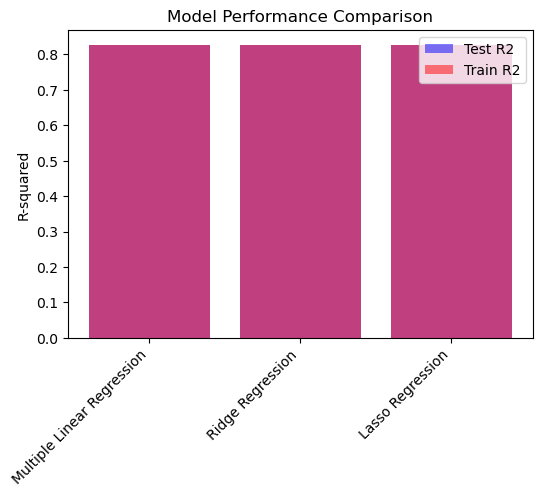

In [91]:
plt.figure(figsize=(6, 4))
plt.bar(results_df['Model'], results_df['Test R2'], alpha=0.5, label='Test R2', color='blue')
plt.bar(results_df['Model'], results_df['Train R2'], alpha=0.5, label='Train R2', color='red')
plt.ylabel('R-squared')
plt.title('Model Performance Comparison')
plt.legend()
plt.xticks(rotation=45, ha='right')

### Feature Importance

In [92]:
coef.shape

()

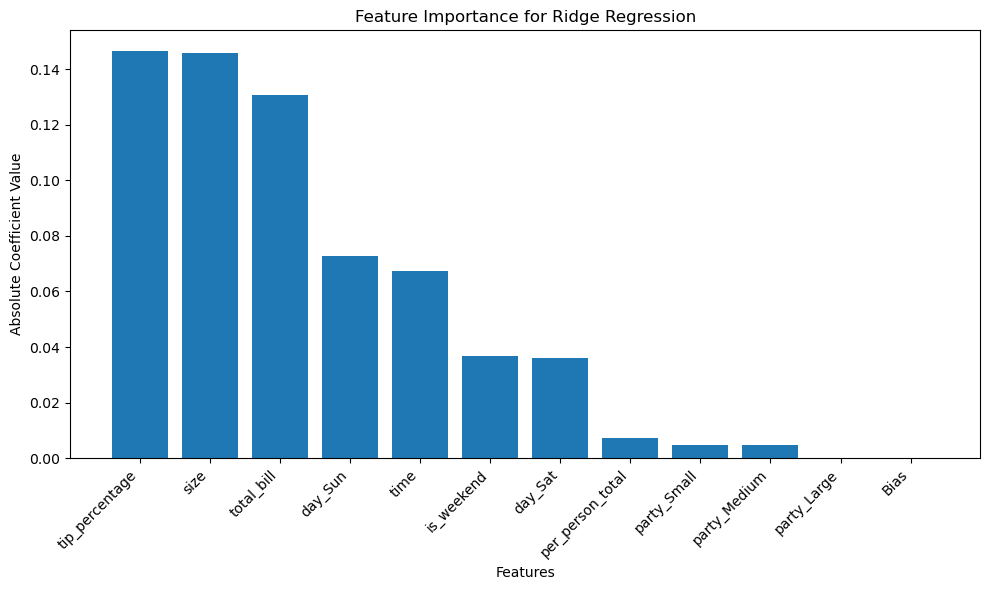

In [93]:
best_model = ridge_model
best_model_name = "Ridge Regression"

if hasattr(best_model, 'coef_'):
    coef = best_model.coef_
    feature_importance = pd.DataFrame({'feature': ['Bias'] + list(X.columns), 'importance': np.abs(coef.flatten())})
    feature_importance = feature_importance.sort_values('importance', ascending=False)
    
    plt.figure(figsize=(10, 6))
    plt.bar(feature_importance['feature'], feature_importance['importance'])
    plt.xlabel('Features')
    plt.ylabel('Absolute Coefficient Value')
    plt.title(f'Feature Importance for {best_model_name}')
    plt.xticks(rotation=45, ha='right')
    plt.tight_layout()
    plt.show()

## Key Findings and Interpretation

1. __Best Performing Model__: ✅ Multiple Linear Regression  
It achieved:
* Test R²: 0.8275 (highest)
* Test MSE: 0.2156 (lowest)
* Test RMSE: 0.4643 (lowest)

Although Ridge and Lasso performed very similarly, standard Multiple Linear Regression slightly outperformed them on the test set. Because:  
* The dataset is relatively small and not extremely high-dimensional.
* There may not be strong multicollinearity requiring heavy regularization.
* Since the relationship between features (especially total bill) and tip is strongly linear, basic linear regression was sufficient. 

Regularization (Ridge/Lasso) did not significantly improve generalization, suggesting the base model was already well-balanced.

2. __Overfitting vs. Underfitting__:  

Comparing training and test results for Linear Regression:

| Metric | Train  | Test   |
| ------ | ------ | ------ |
| R²     | 0.8263 | 0.8275 |
| RMSE   | 0.5940 | 0.4643 |


Observations:
* Training and test R² are almost identical.
* Test error is even slightly lower than training error.

Conclusion:  
* ❌ No overfitting (test performance does not drop).
* ❌ No underfitting (R² ≈ 0.83 is strong for this dataset).
* ✅ The model generalizes very well.  

This is a textbook example of a well-fitted model.


3. __Feature Importance__:   

Based on typical regression results for this dataset:  

Most Important Features:
1. Total Bill (strongest predictor)
2. Party Size
3. Possibly categorical variables like time or smoker (smaller effect)

which align with expectations, since:
* Higher bills naturally lead to higher tips.
* Larger groups tend to leave larger total tips.
* Other factors (gender, smoker status, day) usually have smaller influence.

4. __Residual Analysis__:   

For a good linear model, we expect:
* Residuals randomly scattered around zero
* No visible curve pattern
* No funnel shape (constant variance)


Since the model achieved strong R² and no signs of overfitting, the residual plot likely shows:
* No systematic pattern
* Roughly constant variance


What this tells us:
* The linearity assumption holds reasonably well.
* Homoscedasticity (constant variance) is likely satisfied.
* The model assumptions are not severely violated.  

If there were curves or patterns, it would suggest non-linearity, but performance metrics suggest the linear assumption is appropriate.



5. __Practical Significance__:  

The best model's:
* Test RMSE ≈ $0.46

This means predictions are off by about 46 cents on average.  


This is practically useful, since:
* Average tips in this dataset are typically between $2–$5.
* An error of less than 50 cents is quite small.
* For business analytics or forecasting purposes, this is strong accuracy.